In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import ast
from collections import Counter

In [2]:
user_movies = pd.read_csv("../data/enriched_movies.csv")

In [3]:
user_movies.head()

,Name,Year,Rating,tmdb_id,genres,director,cast
0,The Usual Suspects,1995,5.0,629.0,"['Drama', 'Crime', 'Thriller']",Bryan Singer,"['Stephen Baldwin', 'Gabriel Byrne', 'Benicio ..."
1,Good Will Hunting,1997,5.0,489.0,['Drama'],Gus Van Sant,"['Matt Damon', 'Robin Williams', 'Ben Affleck'..."
2,Scream,1996,5.0,4232.0,"['Crime', 'Horror', 'Mystery']",Wes Craven,"['Neve Campbell', 'Skeet Ulrich', 'Rose McGowa..."
3,A Few Good Men,1992,5.0,881.0,['Drama'],Rob Reiner,"['Tom Cruise', 'Jack Nicholson', 'Demi Moore',..."
4,No Country for Old Men,2007,5.0,6977.0,"['Crime', 'Thriller', 'Western']",Joel Coen,"['Javier Bardem', 'Tommy Lee Jones', 'Josh Bro..."


In [4]:
user_movies.columns.to_list()

['Name', 'Year', 'Rating', 'tmdb_id', 'genres', 'director', 'cast']

In [5]:
# Check out target variable
user_movies["Rating"].nunique() 

8

<Axes: xlabel='Rating', ylabel='Count'>

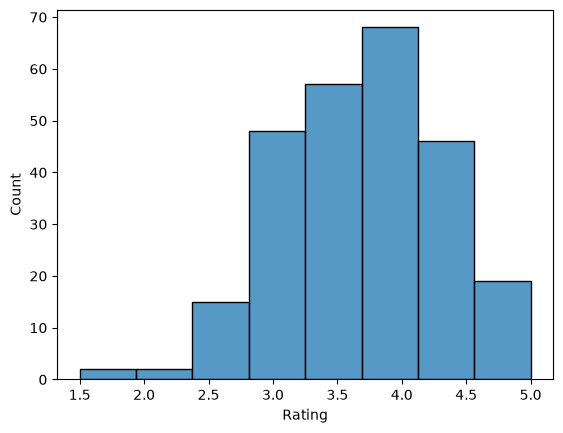

In [6]:
# Visualize target variable distribution
sns.histplot(data=user_movies, x="Rating", bins=8, kde=False)

In [7]:
user_movies.info()

<class 'pandas.DataFrame'>
RangeIndex: 257 entries, 0 to 256
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      257 non-null    str    
 1   Year      257 non-null    int64  
 2   Rating    257 non-null    float64
 3   tmdb_id   256 non-null    float64
 4   genres    256 non-null    str    
 5   director  255 non-null    str    
 6   cast      256 non-null    str    
dtypes: float64(2), int64(1), str(4)
memory usage: 49.2 KB


##### Get One-Hot Columns for Actors in Cast

In [8]:
def parse_cast(value):
    if isinstance(value, list):
        return value

    if isinstance(value, str) and value.strip():
        try:
            parsed = ast.literal_eval(value)
            return parsed if isinstance(parsed, list) else []
        except (ValueError, SyntaxError):
            return []

    return []

actor_counts = Counter(
    actor
    for cast_value in user_movies["cast"]
    for actor in parse_cast(cast_value)
)

top_actors = [
    actor
    for actor, count in actor_counts.most_common(200)
]

In [9]:
parsed_cast = user_movies["cast"].apply(parse_cast)

cast_features = pd.DataFrame(
    {
        f"cast_{actor}": parsed_cast.apply(
            lambda cast_list, actor=actor: int(actor in cast_list)
        )
        for actor in top_actors
    },
    index=user_movies.index,
)

user_movies = pd.concat(
    [user_movies, cast_features],
    axis=1,
)

##### Get One-Hot Columns for Genre

In [10]:
def parse_genre(value):
    if isinstance(value, list):
        return value

    if isinstance(value, str) and value.strip():
        try:
            parsed = ast.literal_eval(value)
            return parsed if isinstance(parsed, list) else []
        except (ValueError, SyntaxError):
            return []

    return []

genre_counts = Counter(
    genre
    for genre_value in user_movies["genres"]
    for genre in parse_genre(genre_value)
)

top_genres = [
    genre
    for genre, count in genre_counts.most_common(20)
]


In [11]:
parsed_genres = user_movies["genres"].apply(parse_genre)

genre_features = pd.DataFrame(
    {
        f"genre_{genre}": parsed_genres.apply(
            lambda genre_list, genre=genre: int(genre in genre_list)
        )
        for genre in top_genres
    },
    index=user_movies.index,
)

user_movies = pd.concat(
    [user_movies, genre_features],
    axis=1,
)

##### Get Dummies for Directors

In [12]:
counts = user_movies["director"].value_counts()

user_movies["director_clean"] = user_movies["director"].where(
    user_movies["director"].map(counts) >= 3,
    "Other"
)

user_movies = pd.get_dummies(user_movies, columns=["director_clean"])

In [13]:
user_movies.shape

(257, 240)

In [14]:
# Check to make sure the one hot columns are now included in the DataFrame
user_movies.columns.to_list()

['Name',
 'Year',
 'Rating',
 'tmdb_id',
 'genres',
 'director',
 'cast',
 'cast_Matt Damon',
 'cast_Edward Norton',
 'cast_Robert De Niro',
 'cast_Christian Bale',
 'cast_Brad Pitt',
 'cast_Leonardo DiCaprio',
 'cast_Josh Brolin',
 'cast_Ryan Gosling',
 'cast_Anne Hathaway',
 'cast_Ralph Fiennes',
 'cast_Timothée Chalamet',
 'cast_Emily Blunt',
 'cast_Bradley Cooper',
 'cast_Jack Nicholson',
 'cast_Gwyneth Paltrow',
 'cast_Joaquin Phoenix',
 'cast_Rachel McAdams',
 'cast_Robert Pattinson',
 'cast_Benicio del Toro',
 'cast_Kevin Spacey',
 'cast_Tom Cruise',
 'cast_Harvey Keitel',
 'cast_Tom Hanks',
 'cast_Daniel Craig',
 'cast_Rosamund Pike',
 'cast_Tom Hardy',
 'cast_Frances McDormand',
 'cast_Andrew Garfield',
 'cast_Jason Schwartzman',
 'cast_Ray Liotta',
 'cast_Philip Seymour Hoffman',
 'cast_Cillian Murphy',
 'cast_Dev Patel',
 'cast_Ben Affleck',
 'cast_Javier Bardem',
 'cast_Woody Harrelson',
 'cast_Laurence Fishburne',
 'cast_Adrien Brody',
 'cast_Willem Dafoe',
 'cast_Michael 

In [15]:
user_movies.head()

,Name,Year,Rating,tmdb_id,genres,director,cast,cast_Matt Damon,cast_Edward Norton,cast_Robert De Niro,...,director_clean_Denis Villeneuve,director_clean_Jimmy Chin,director_clean_Martin Scorsese,director_clean_Other,director_clean_Paul Thomas Anderson,director_clean_Quentin Tarantino,director_clean_Rian Johnson,director_clean_Stanley Kubrick,director_clean_Steven Spielberg,director_clean_Wes Anderson
0,The Usual Suspects,1995,5.0,629.0,"['Drama', 'Crime', 'Thriller']",Bryan Singer,"['Stephen Baldwin', 'Gabriel Byrne', 'Benicio ...",0,0,0,...,False,False,False,True,False,False,False,False,False,False
1,Good Will Hunting,1997,5.0,489.0,['Drama'],Gus Van Sant,"['Matt Damon', 'Robin Williams', 'Ben Affleck'...",1,0,0,...,False,False,False,True,False,False,False,False,False,False
2,Scream,1996,5.0,4232.0,"['Crime', 'Horror', 'Mystery']",Wes Craven,"['Neve Campbell', 'Skeet Ulrich', 'Rose McGowa...",0,0,0,...,False,False,False,True,False,False,False,False,False,False
3,A Few Good Men,1992,5.0,881.0,['Drama'],Rob Reiner,"['Tom Cruise', 'Jack Nicholson', 'Demi Moore',...",0,0,0,...,False,False,False,True,False,False,False,False,False,False
4,No Country for Old Men,2007,5.0,6977.0,"['Crime', 'Thriller', 'Western']",Joel Coen,"['Javier Bardem', 'Tommy Lee Jones', 'Josh Bro...",0,0,0,...,False,False,False,True,False,False,False,False,False,False


In [18]:
user_movies.info()

<class 'pandas.DataFrame'>
RangeIndex: 257 entries, 0 to 256
Columns: 240 entries, Name to director_clean_Wes Anderson
dtypes: bool(14), float64(2), int64(220), str(4)
memory usage: 492.4 KB


In [19]:
# Save the new dataset that is ready for modeling
user_movies.to_csv("../data/initial_modeling_data.csv", index=False)